# Linear Regression Paper Notebook


In [1]:
# ============================================================
# Imports and configuration
# ============================================================

import os
import sys
import json
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler


REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.parse_data import (
    load_dataset,
    split_by_subject,
    normalize_items,
    build_sliding_windows,
)


class Config:
    root_dir = "data/pooled_stratified_share"

    M = 50
    H = 3
    stride = 1

    test_ratio = 0.2
    random_state = 42

    alpha = 1.0
    bins = 32

    results_dir = "results_paper/linear_regression"
    figure_dir = "results_paper/linear_regression/figures"
    checkpoint_dir = "checkpoints_paper/linear_regression"

    scatter_max_points = 50000
    min_future_std_quantile = 0.10


CONFIG = Config()

Path(CONFIG.results_dir).mkdir(parents=True, exist_ok=True)
Path(CONFIG.figure_dir).mkdir(parents=True, exist_ok=True)
Path(CONFIG.checkpoint_dir).mkdir(parents=True, exist_ok=True)

print("Linear regression paper configuration")
for key, value in vars(CONFIG).items():
    if not key.startswith("__"):
        print(f"{key}: {value}")


Linear regression paper configuration


/Users/oscarzhang/Desktop/Project Folder/fmri_forecasting/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# Utility functions
# ============================================================

def safe_name(name):
    return str(name).lower().replace(" ", "_").replace("/", "_")


def savefig(name, dpi=300):
    path = Path(CONFIG.figure_dir) / name
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path}")
    plt.show()


def flatten_features(X):
    X = np.asarray(X)
    if X.ndim != 3:
        raise ValueError(f"Expected X shape (N, M, ROI), got {X.shape}")
    return X.reshape(X.shape[0], -1)


def flatten_targets(Y):
    Y = np.asarray(Y)
    if Y.ndim == 3:
        return Y.reshape(Y.shape[0], -1)
    return Y


def unflatten_predictions(preds, target_shape):
    preds = np.asarray(preds, dtype=np.float32)
    if preds.shape == target_shape:
        return preds
    return preds.reshape(target_shape)


def flatten_time_roi(arr):
    arr = np.asarray(arr)
    if arr.ndim == 3:
        return arr.reshape(-1, arr.shape[-1])
    return arr


def compute_rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def compute_naive_predictions(X_test, H):
    return np.repeat(X_test[:, -1:, :], H, axis=1)


def compute_rmsse(y_true, y_pred, X_train, eps=1e-8):
    pred_mse = np.mean((y_true - y_pred) ** 2, axis=(0, 1))
    naive_diff = X_train[:, 1:, :] - X_train[:, :-1, :]
    naive_mse = np.mean(naive_diff ** 2, axis=(0, 1))
    naive_mse = np.maximum(naive_mse, eps)
    rmsse_per_roi = np.sqrt(pred_mse / naive_mse)
    return float(np.mean(rmsse_per_roi))


def compute_pve(y_true, y_pred, eps=1e-12):
    residual_var = np.var(y_true - y_pred)
    target_var = np.var(y_true)
    return float(1.0 - residual_var / (target_var + eps))


def compute_overall_corr(y_true, y_pred):
    yt = np.asarray(y_true).ravel()
    yp = np.asarray(y_pred).ravel()
    if yt.std() < 1e-12 or yp.std() < 1e-12:
        return np.nan
    return float(np.corrcoef(yt, yp)[0, 1])


def horizon_rmse(y_true, y_pred):
    rows = []
    for h in range(y_true.shape[1]):
        rows.append({
            "horizon": h + 1,
            "rmse": compute_rmse(y_true[:, h, :], y_pred[:, h, :]),
        })
    return pd.DataFrame(rows)


def empirical_entropy_1d(x, bins=32, eps=1e-12):
    x = np.asarray(x).ravel()
    hist, _ = np.histogram(x, bins=bins)
    p = hist.astype(np.float64)
    total = p.sum()
    if total <= 0:
        return np.nan
    p = p / total
    p = p[p > 0]
    return float(-np.sum(p * np.log(p + eps)))


def empirical_mi_2d(x, y, bins=32, eps=1e-12):
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) == 0 or x.std() < eps or y.std() < eps:
        return 0.0

    joint_hist, _, _ = np.histogram2d(x, y, bins=bins)
    joint = joint_hist.astype(np.float64)
    total = joint.sum()

    if total <= 0:
        return 0.0

    pxy = joint / total
    px = pxy.sum(axis=1, keepdims=True)
    py = pxy.sum(axis=0, keepdims=True)

    mask = pxy > 0
    mi = np.sum(pxy[mask] * np.log((pxy[mask] + eps) / ((px @ py)[mask] + eps)))
    return float(max(mi, 0.0))


def compute_per_roi_metrics(y_true, y_pred, bins=32, eps=1e-12):
    yt = flatten_time_roi(y_true)
    yp = flatten_time_roi(y_pred)

    rows = []

    for r in range(yt.shape[1]):
        true_r = yt[:, r]
        pred_r = yp[:, r]
        residual = true_r - pred_r

        mse = float(np.mean(residual ** 2))
        rmse = float(np.sqrt(mse))

        if true_r.std() < eps or pred_r.std() < eps:
            corr = np.nan
        else:
            corr = float(np.corrcoef(true_r, pred_r)[0, 1])

        pve = float(1.0 - np.var(residual) / (np.var(true_r) + eps))
        entropy = empirical_entropy_1d(true_r, bins=bins, eps=eps)
        mi = empirical_mi_2d(true_r, pred_r, bins=bins, eps=eps)

        rows.append({
            "roi": r,
            "mse": mse,
            "rmse": rmse,
            "corr": corr,
            "pve": pve,
            "empirical_entropy": entropy,
            "empirical_mi_true_pred": mi,
            "past_std": np.nan,
            "future_std": np.nan,
            "pred_std": np.nan,
        })

    return pd.DataFrame(rows)


def add_roi_signal_stats(per_roi_df, X_test, Y_test, preds):
    rows = []
    for r in range(Y_test.shape[-1]):
        rows.append({
            "roi": r,
            "past_std": float(X_test[:, :, r].std()),
            "future_std": float(Y_test[:, :, r].std()),
            "pred_std": float(preds[:, :, r].std()),
        })

    stats_df = pd.DataFrame(rows)
    clean_df = per_roi_df.drop(columns=["past_std", "future_std", "pred_std"], errors="ignore")
    return clean_df.merge(stats_df, on="roi", how="left")


In [3]:
# ============================================================
# Load, split, normalize, and window dataset
# ============================================================

root_dir = Path(CONFIG.root_dir)

if not root_dir.exists():
    raise FileNotFoundError(
        f"Dataset folder not found: {root_dir}. "
        "Update CONFIG.root_dir to the extracted dataset folder."
    )

print("=" * 80)
print("Loading raw dataset")
print("=" * 80)

start = time.time()
dataset = load_dataset(root_dir)
load_time = time.time() - start

print(f"Loaded {len(dataset)} runs in {load_time:.2f} seconds")

print("\nSplitting dataset by subject")
train_items, test_items = split_by_subject(
    dataset,
    test_ratio=CONFIG.test_ratio,
    test_subjects=None,
    random_state=CONFIG.random_state,
    verbose=True,
)

print("\nNormalizing train and test groups separately")
train_items = normalize_items(train_items)
test_items = normalize_items(test_items)

print("\nBuilding sliding windows")
X_train, Y_train = build_sliding_windows(
    train_items,
    M=CONFIG.M,
    H=CONFIG.H,
    stride=CONFIG.stride,
)

X_test, Y_test = build_sliding_windows(
    test_items,
    M=CONFIG.M,
    H=CONFIG.H,
    stride=CONFIG.stride,
)

if len(X_train) == 0 or len(X_test) == 0:
    raise ValueError("No windows were created. Check M, H, stride, and dataset length.")

n_roi = X_train.shape[2]

metadata = {
    "root_dir": str(root_dir),
    "num_runs_loaded": len(dataset),
    "num_train_runs": len(train_items),
    "num_test_runs": len(test_items),
    "X_train_shape": list(X_train.shape),
    "Y_train_shape": list(Y_train.shape),
    "X_test_shape": list(X_test.shape),
    "Y_test_shape": list(Y_test.shape),
    "n_roi": int(n_roi),
    "M": int(CONFIG.M),
    "H": int(CONFIG.H),
    "stride": int(CONFIG.stride),
    "test_ratio": float(CONFIG.test_ratio),
    "random_state": int(CONFIG.random_state),
}

with open(Path(CONFIG.results_dir) / "dataset_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

metadata


Loading raw dataset
Scanning and loading dataset (optimized fixed schema mode)...
Loaded: 2144 runs from 6 subjects
Subjects: ['subjOenz4SHyaO', 'subjQX6R7rImeb', 'subjoVC0sHUB_P', 'subjqFdsBbuiHF', 'subjtySNgRhV65', 'subjxpYwO4azeZ']
Loaded 2144 runs in 0.98 seconds

Splitting dataset by subject
Train subjects: ['subjqFdsBbuiHF', 'subjoVC0sHUB_P', 'subjxpYwO4azeZ', 'subjtySNgRhV65']
Test subjects : ['subjQX6R7rImeb', 'subjOenz4SHyaO']
Train runs: 1440
Test runs : 704

Normalizing train and test groups separately

Building sliding windows


{'root_dir': 'data/pooled_stratified_share',
 'num_runs_loaded': 2144,
 'num_train_runs': 1440,
 'num_test_runs': 704,
 'X_train_shape': [250560, 50, 19],
 'Y_train_shape': [250560, 3, 19],
 'X_test_shape': [122496, 50, 19],
 'Y_test_shape': [122496, 3, 19],
 'n_roi': 19,
 'M': 50,
 'H': 3,
 'stride': 1,
 'test_ratio': 0.2,
 'random_state': 42}

In [4]:
# ============================================================
# Train ridge regression forecaster
# ============================================================

X_train_flat = flatten_features(X_train)
Y_train_flat = flatten_targets(Y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)

model = Ridge(alpha=CONFIG.alpha)

start = time.time()
model.fit(X_train_scaled, Y_train_flat)
train_time_minutes = (time.time() - start) / 60

model_path = Path(CONFIG.checkpoint_dir) / "linear_regression_ridge.joblib"
scaler_path = Path(CONFIG.checkpoint_dir) / "linear_regression_scaler.joblib"

joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)

print(f"Saved model: {model_path}")
print(f"Saved scaler: {scaler_path}")
print(f"Finished training in {train_time_minutes:.4f} minutes")


Saved model: checkpoints_paper/linear_regression/linear_regression_ridge.joblib
Saved scaler: checkpoints_paper/linear_regression/linear_regression_scaler.joblib
Finished training in 0.0111 minutes


In [5]:
# ============================================================
# Predict held-out test set
# ============================================================

X_test_flat = flatten_features(X_test)
X_test_scaled = scaler.transform(X_test_flat)

preds_flat = model.predict(X_test_scaled)
preds = unflatten_predictions(preds_flat, Y_test.shape)

naive_preds = compute_naive_predictions(X_test, CONFIG.H)

print(f"Predictions shape: {preds.shape}")
print(f"Targets shape    : {Y_test.shape}")


Predictions shape: (122496, 3, 19)
Targets shape    : (122496, 3, 19)


In [6]:
# ============================================================
# Overall metrics
# ============================================================

model_rmse = compute_rmse(Y_test, preds)
naive_rmse = compute_rmse(Y_test, naive_preds)
rmsse = compute_rmsse(Y_test, preds, X_train)
pve = compute_pve(Y_test, preds)
corr = compute_overall_corr(Y_test, preds)

per_roi_df = compute_per_roi_metrics(
    Y_test,
    preds,
    bins=CONFIG.bins,
)

per_roi_df = add_roi_signal_stats(
    per_roi_df,
    X_test=X_test,
    Y_test=Y_test,
    preds=preds,
)

mean_empirical_mi = float(per_roi_df["empirical_mi_true_pred"].mean())
mean_empirical_entropy = float(per_roi_df["empirical_entropy"].mean())

summary = {
    "model": "Linear Regression Ridge",
    "M": int(CONFIG.M),
    "H": int(CONFIG.H),
    "stride": int(CONFIG.stride),
    "n_roi": int(n_roi),
    "alpha": float(CONFIG.alpha),
    "rmse": float(model_rmse),
    "naive_rmse": float(naive_rmse),
    "rmsse": float(rmsse),
    "pve": float(pve),
    "corr": float(corr),
    "mean_empirical_mi_true_pred": mean_empirical_mi,
    "mean_empirical_entropy": mean_empirical_entropy,
    "beat_naive": bool(model_rmse < naive_rmse),
    "train_time_minutes": float(train_time_minutes),
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(Path(CONFIG.results_dir) / "summary_for_report.csv", index=False)

with open(Path(CONFIG.results_dir) / "summary_for_report.json", "w") as f:
    json.dump(summary, f, indent=2)

per_roi_df.to_csv(Path(CONFIG.results_dir) / "per_roi_metrics.csv", index=False)

horizon_df = horizon_rmse(Y_test, preds)
horizon_df.to_csv(Path(CONFIG.results_dir) / "horizon_rmse.csv", index=False)

display(summary_df)
display(horizon_df)
display(per_roi_df.sort_values("pve", ascending=False))


,model,M,H,stride,n_roi,alpha,rmse,naive_rmse,rmsse,pve,corr,mean_empirical_mi_true_pred,mean_empirical_entropy,beat_naive,train_time_minutes
0,Linear Regression Ridge,50,3,1,19,1.0,0.799327,0.991941,1.008423,0.269832,0.519877,0.177879,2.200716,True,0.011054


,horizon,rmse
0,1,0.701868
1,2,0.825717
2,3,0.861593


,roi,mse,rmse,corr,pve,empirical_entropy,empirical_mi_true_pred,past_std,future_std,pred_std
11,11,0.460131,0.678330,0.707338,0.490410,2.080144,0.331406,0.947589,0.950151,0.577457
1,1,0.484401,0.695989,0.648988,0.414128,2.033455,0.293808,0.911432,0.908888,0.513501
13,13,0.543133,0.736976,0.638371,0.407483,2.670814,0.271690,0.959407,0.956156,0.616038
3,3,0.513802,0.716800,0.630841,0.393772,2.037298,0.253286,0.920976,0.918759,0.639050
15,15,0.629705,0.793539,0.566595,0.319687,2.101521,0.180933,0.960148,0.959964,0.579096
2,2,0.598379,0.773549,0.563874,0.317116,2.049665,0.201754,0.942593,0.936073,0.500726
14,14,0.637769,0.798604,0.548571,0.295002,2.379247,0.182602,0.950226,0.949435,0.593931
5,5,0.638724,0.799202,0.530979,0.281636,2.114452,0.166691,0.938841,0.942559,0.516858
7,7,0.604316,0.777378,0.514599,0.262816,2.028646,0.164890,0.913186,0.904214,0.424909
17,17,0.697066,0.834905,0.509021,0.259102,2.234079,0.145641,0.966488,0.969765,0.493129


In [7]:
# ============================================================
# ROI selection for report figures
# ============================================================

future_std_cutoff = float(per_roi_df["future_std"].quantile(CONFIG.min_future_std_quantile))

valid_roi_df = per_roi_df[
    (per_roi_df["future_std"] > future_std_cutoff)
    & np.isfinite(per_roi_df["pve"])
    & np.isfinite(per_roi_df["corr"])
].copy()

if len(valid_roi_df) < 3:
    valid_roi_df = per_roi_df[
        np.isfinite(per_roi_df["pve"])
        & np.isfinite(per_roi_df["corr"])
    ].copy()

roi_ranked = valid_roi_df.sort_values("pve", ascending=False).reset_index(drop=True)

best_roi = int(roi_ranked.iloc[0]["roi"])
median_roi = int(roi_ranked.iloc[len(roi_ranked) // 2]["roi"])
worst_roi = int(roi_ranked.iloc[-1]["roi"])

selected_rois = {
    "best_roi": best_roi,
    "median_roi": median_roi,
    "worst_roi": worst_roi,
    "selection_metric": "pve",
    "future_std_cutoff": future_std_cutoff,
}

with open(Path(CONFIG.results_dir) / "selected_rois.json", "w") as f:
    json.dump(selected_rois, f, indent=2)

print("Selected ROIs")
print(selected_rois)

display(roi_ranked[["roi", "rmse", "pve", "corr", "future_std", "pred_std", "empirical_mi_true_pred"]])


Selected ROIs
{'best_roi': 11, 'median_roi': 17, 'worst_roi': 8, 'selection_metric': 'pve', 'future_std_cutoff': 0.9079530596733093}


,roi,rmse,pve,corr,future_std,pred_std,empirical_mi_true_pred
0,11,0.678330,0.490410,0.707338,0.950151,0.577457,0.331406
1,1,0.695989,0.414128,0.648988,0.908888,0.513501,0.293808
2,13,0.736976,0.407483,0.638371,0.956156,0.616038,0.271690
3,3,0.716800,0.393772,0.630841,0.918759,0.639050,0.253286
4,15,0.793539,0.319687,0.566595,0.959964,0.579096,0.180933
5,2,0.773549,0.317116,0.563874,0.936073,0.500726,0.201754
6,14,0.798604,0.295002,0.548571,0.949435,0.593931,0.182602
7,5,0.799202,0.281636,0.530979,0.942559,0.516858,0.166691
8,17,0.834905,0.259102,0.509021,0.969765,0.493129,0.145641
9,12,0.817112,0.252627,0.517801,0.945142,0.607030,0.160624


In [8]:
# ============================================================
# Plotting functions
# ============================================================

def plot_horizon_rmse(horizon_df):
    plt.figure(figsize=(7, 4))
    plt.plot(horizon_df["horizon"], horizon_df["rmse"], marker="o", linewidth=2)
    plt.xlabel("Forecast Horizon")
    plt.ylabel("RMSE")
    plt.title("Linear Regression: Horizon-wise RMSE")
    plt.grid(True, linestyle=":", alpha=0.7)
    savefig("horizon_rmse.png")


def plot_per_roi_bar(df, metric, title, ylabel, filename, ascending=False):
    plot_df = df.sort_values(metric, ascending=ascending)

    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["roi"].astype(str), plot_df[metric])
    plt.xlabel("ROI")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(axis="y", linestyle=":", alpha=0.7)
    savefig(filename)


def plot_prediction_scatter(y_true, y_pred, max_points=50000):
    yt = np.asarray(y_true).ravel()
    yp = np.asarray(y_pred).ravel()

    rng = np.random.default_rng(0)
    if len(yt) > max_points:
        idx = rng.choice(len(yt), size=max_points, replace=False)
        yt = yt[idx]
        yp = yp[idx]

    lim_low = float(min(yt.min(), yp.min()))
    lim_high = float(max(yt.max(), yp.max()))

    plt.figure(figsize=(6, 6))
    plt.scatter(yt, yp, s=4, alpha=0.25)
    plt.plot([lim_low, lim_high], [lim_low, lim_high], linestyle="--", linewidth=2, label="Perfect prediction")
    plt.xlabel("Ground Truth")
    plt.ylabel("Prediction")
    plt.title("Linear Regression Prediction vs Ground Truth")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.7)
    savefig("prediction_vs_truth_scatter.png")


def choose_sample_for_roi(roi_idx, quantile=0.85):
    activity = np.abs(Y_test[:, :, roi_idx]).mean(axis=1)
    order = np.argsort(activity)
    index = int(order[int((len(order) - 1) * quantile)])
    return index


def plot_forecast_example(roi_idx, sample_idx, title, filename):
    past_time = np.arange(CONFIG.M)
    future_time = np.arange(CONFIG.M, CONFIG.M + CONFIG.H)

    plt.figure(figsize=(10, 5))

    plt.plot(
        past_time,
        X_test[sample_idx, :, roi_idx],
        label="Past Signal",
        linewidth=2,
        alpha=0.7,
    )

    plt.plot(
        future_time,
        Y_test[sample_idx, :, roi_idx],
        "o-",
        label="Ground Truth",
        linewidth=2,
    )

    plt.plot(
        future_time,
        preds[sample_idx, :, roi_idx],
        "o--",
        label="Prediction",
        linewidth=2,
    )

    plt.axvline(CONFIG.M - 0.5, linestyle="--", label="Forecast Start")
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Signal")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.7)
    savefig(filename)


def plot_empirical_uncertainty_forecast(roi_idx, sample_idx, filename):
    residuals = Y_test[:, :, roi_idx] - preds[:, :, roi_idx]

    q025 = np.quantile(residuals, 0.025, axis=0)
    q160 = np.quantile(residuals, 0.16, axis=0)
    q840 = np.quantile(residuals, 0.84, axis=0)
    q975 = np.quantile(residuals, 0.975, axis=0)

    mean_pred = preds[sample_idx, :, roi_idx]

    lower_68 = mean_pred + q160
    upper_68 = mean_pred + q840
    lower_95 = mean_pred + q025
    upper_95 = mean_pred + q975

    past_time = np.arange(CONFIG.M)
    future_time = np.arange(CONFIG.M, CONFIG.M + CONFIG.H)

    plt.figure(figsize=(10, 5))

    plt.plot(
        past_time,
        X_test[sample_idx, :, roi_idx],
        label="Past Signal",
        linewidth=2,
        alpha=0.7,
    )

    plt.plot(
        future_time,
        Y_test[sample_idx, :, roi_idx],
        "o-",
        label="Ground Truth",
        linewidth=2,
    )

    plt.plot(
        future_time,
        mean_pred,
        "o--",
        label="Prediction Mean",
        linewidth=2,
    )

    plt.fill_between(future_time, lower_95, upper_95, alpha=0.18, label="Empirical 95% Band")
    plt.fill_between(future_time, lower_68, upper_68, alpha=0.30, label="Empirical 68% Band")

    plt.axvline(CONFIG.M - 0.5, linestyle="--", label="Forecast Start")
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Signal")
    plt.title(f"Empirical Probabilistic Forecast | ROI {roi_idx}")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.7)
    savefig(filename)


Saved figure: results_paper/linear_regression/figures/horizon_rmse.png


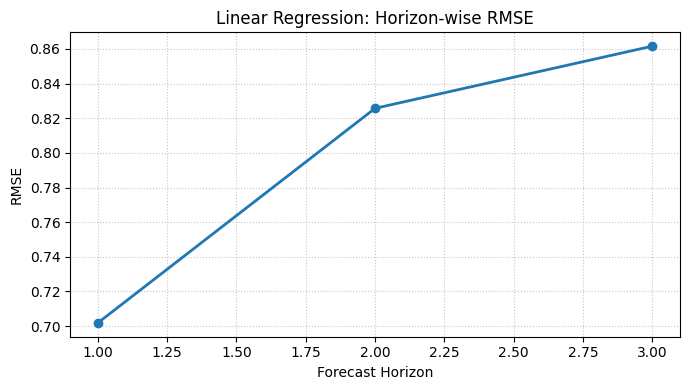

Saved figure: results_paper/linear_regression/figures/per_roi_pve.png


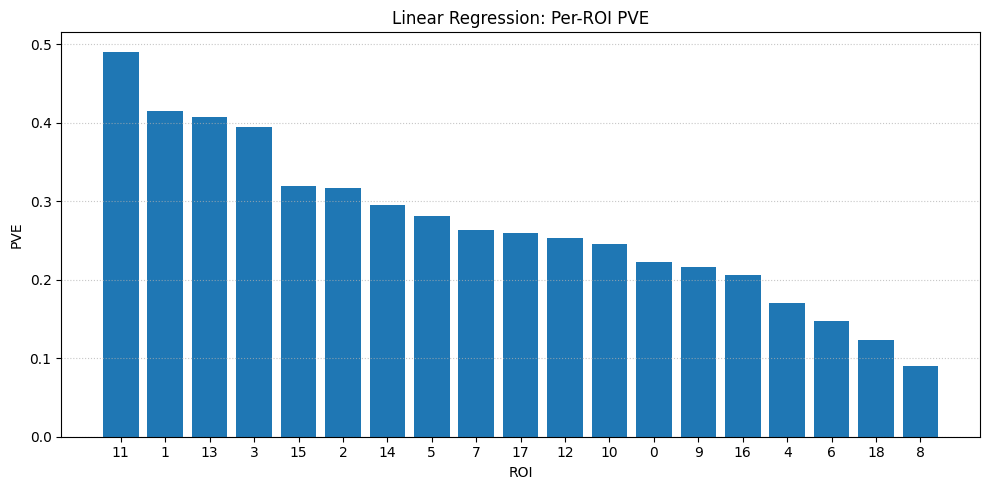

Saved figure: results_paper/linear_regression/figures/per_roi_correlation.png


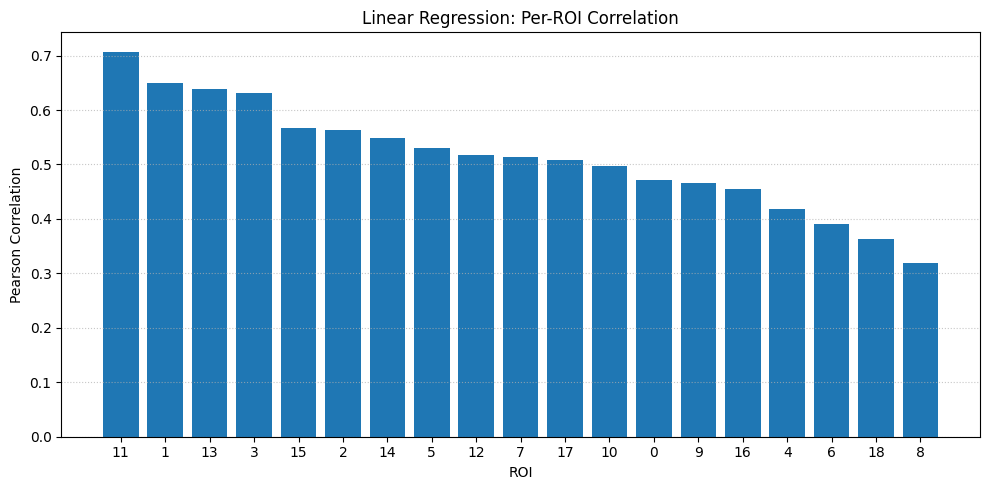

Saved figure: results_paper/linear_regression/figures/per_roi_empirical_mi_true_pred.png


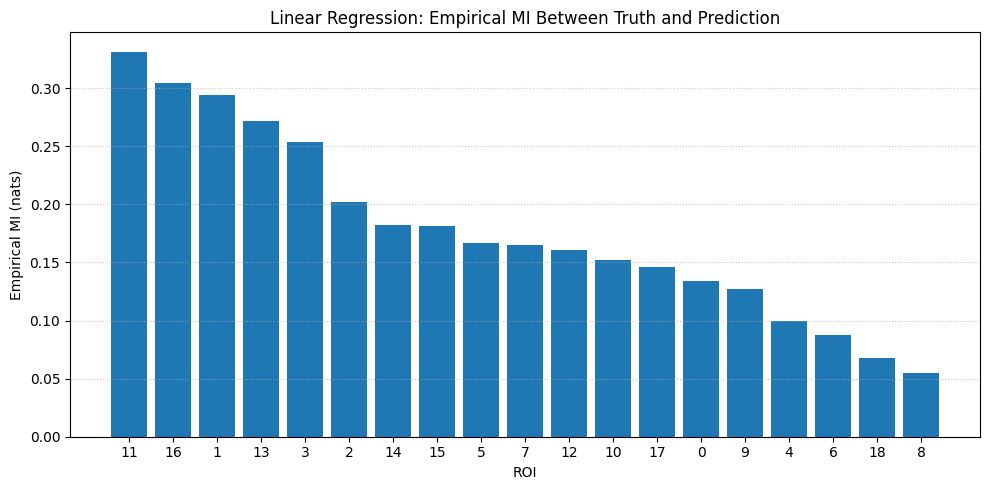

Saved figure: results_paper/linear_regression/figures/prediction_vs_truth_scatter.png


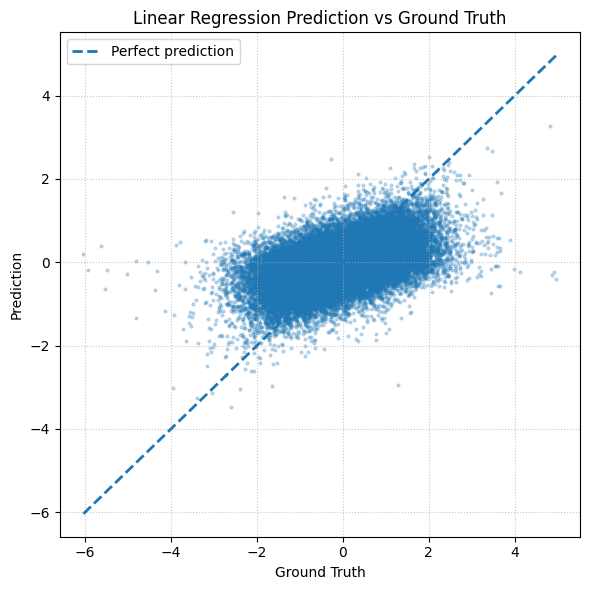

Best ROI 11, sample 31558
Median ROI 17, sample 48801
Worst ROI 8, sample 88837
Saved figure: results_paper/linear_regression/figures/forecast_example_best_roi.png


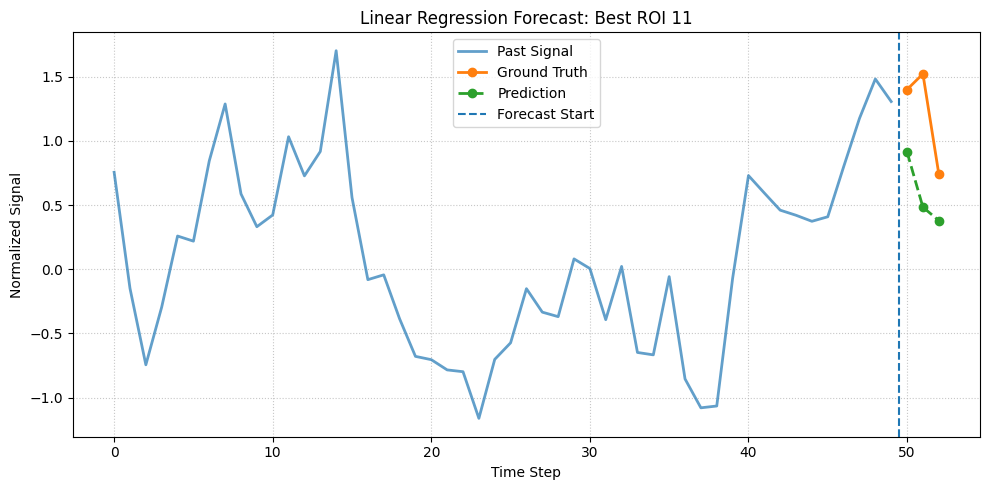

Saved figure: results_paper/linear_regression/figures/forecast_example_median_roi.png


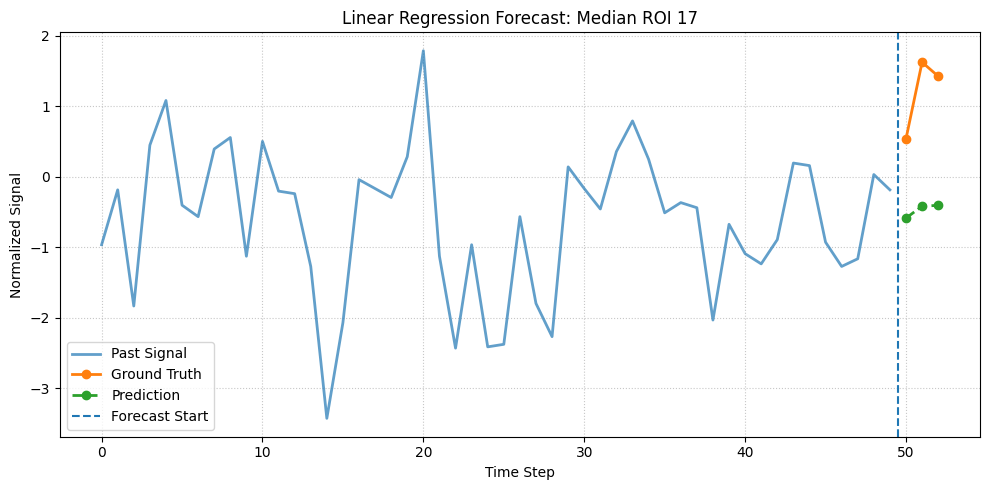

Saved figure: results_paper/linear_regression/figures/forecast_example_worst_roi.png


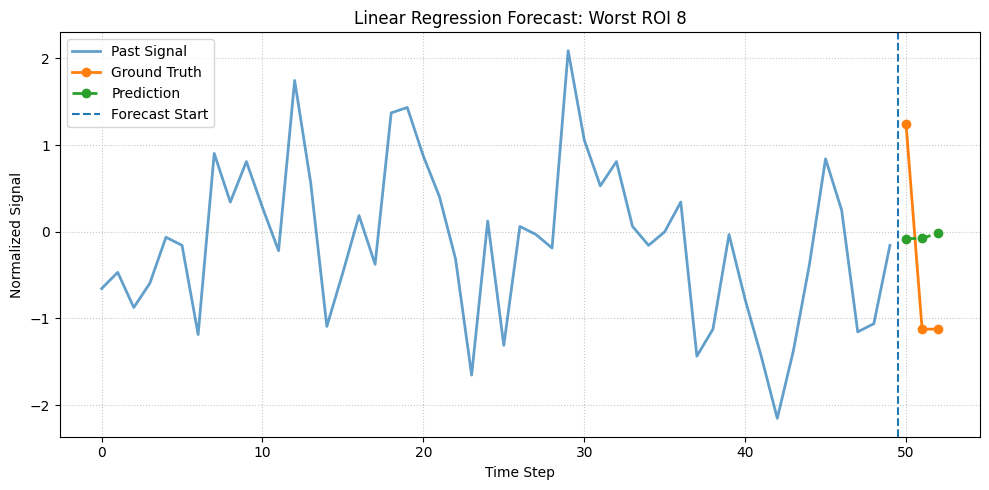

Saved figure: results_paper/linear_regression/figures/empirical_uncertainty_best_roi.png


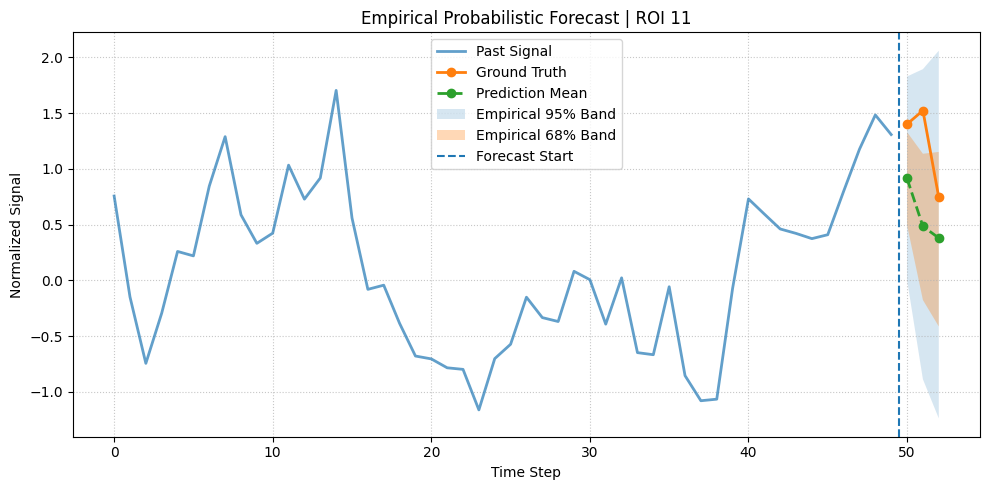

In [9]:
# ============================================================
# Core report figures
# ============================================================

plot_horizon_rmse(horizon_df)

plot_per_roi_bar(
    per_roi_df,
    metric="pve",
    title="Linear Regression: Per-ROI PVE",
    ylabel="PVE",
    filename="per_roi_pve.png",
    ascending=False,
)

plot_per_roi_bar(
    per_roi_df,
    metric="corr",
    title="Linear Regression: Per-ROI Correlation",
    ylabel="Pearson Correlation",
    filename="per_roi_correlation.png",
    ascending=False,
)

plot_per_roi_bar(
    per_roi_df,
    metric="empirical_mi_true_pred",
    title="Linear Regression: Empirical MI Between Truth and Prediction",
    ylabel="Empirical MI (nats)",
    filename="per_roi_empirical_mi_true_pred.png",
    ascending=False,
)

plot_prediction_scatter(
    Y_test,
    preds,
    max_points=CONFIG.scatter_max_points,
)

best_sample = choose_sample_for_roi(best_roi, quantile=0.85)
median_sample = choose_sample_for_roi(median_roi, quantile=0.85)
worst_sample = choose_sample_for_roi(worst_roi, quantile=0.85)

print(f"Best ROI {best_roi}, sample {best_sample}")
print(f"Median ROI {median_roi}, sample {median_sample}")
print(f"Worst ROI {worst_roi}, sample {worst_sample}")

plot_forecast_example(
    roi_idx=best_roi,
    sample_idx=best_sample,
    title=f"Linear Regression Forecast: Best ROI {best_roi}",
    filename="forecast_example_best_roi.png",
)

plot_forecast_example(
    roi_idx=median_roi,
    sample_idx=median_sample,
    title=f"Linear Regression Forecast: Median ROI {median_roi}",
    filename="forecast_example_median_roi.png",
)

plot_forecast_example(
    roi_idx=worst_roi,
    sample_idx=worst_sample,
    title=f"Linear Regression Forecast: Worst ROI {worst_roi}",
    filename="forecast_example_worst_roi.png",
)

plot_empirical_uncertainty_forecast(
    roi_idx=best_roi,
    sample_idx=best_sample,
    filename="empirical_uncertainty_best_roi.png",
)


Saved figure: results_paper/linear_regression/figures/predicted_cross_roi_empirical_mi_heatmap.png


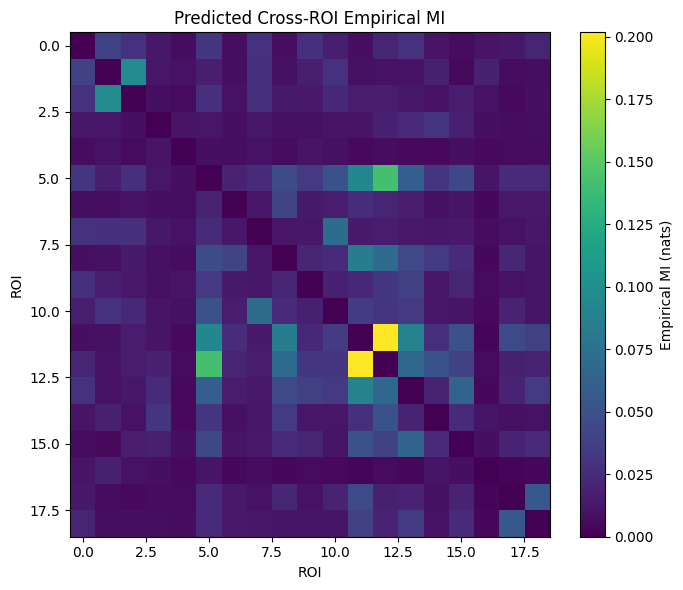

Saved figure: results_paper/linear_regression/figures/true_cross_roi_empirical_mi_heatmap.png


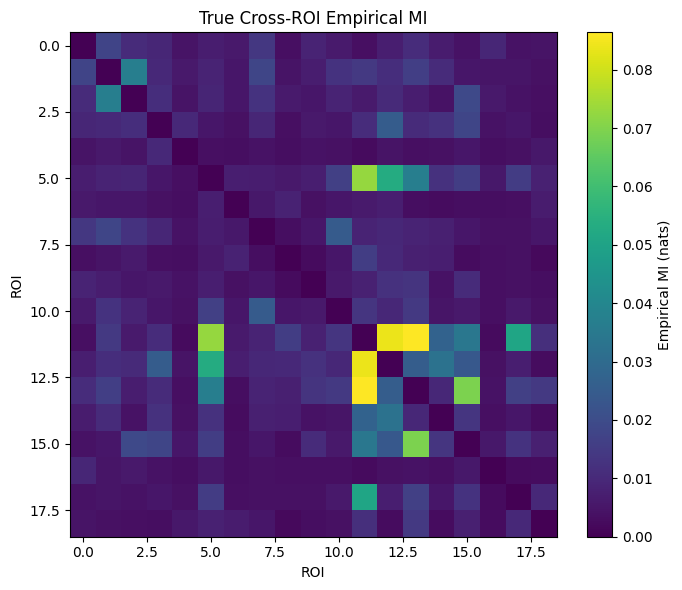

Saved figure: results_paper/linear_regression/figures/cross_roi_empirical_mi_difference_heatmap.png


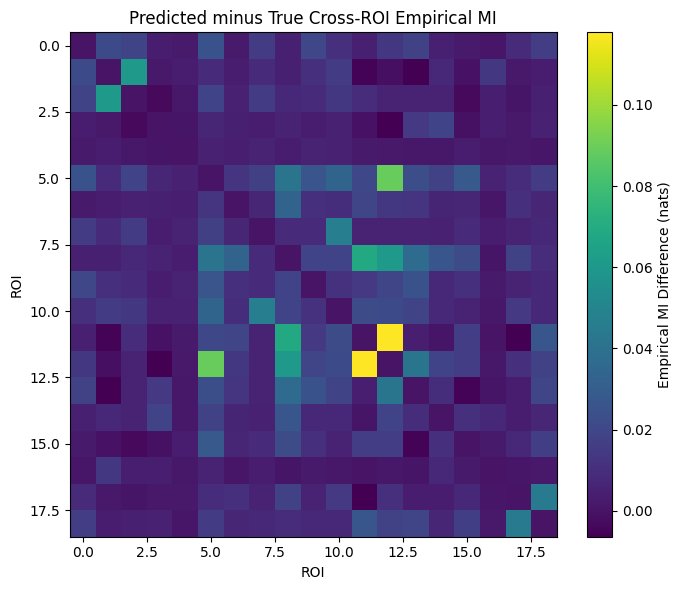

In [10]:
# ============================================================
# Empirical cross-ROI information matrices
# ============================================================

def empirical_cross_roi_mi_matrix(values, bins=32):
    vals = flatten_time_roi(values)
    n_roi = vals.shape[1]
    mat = np.zeros((n_roi, n_roi), dtype=np.float64)

    for i in range(n_roi):
        for j in range(n_roi):
            if i == j:
                mat[i, j] = 0.0
            else:
                mat[i, j] = empirical_mi_2d(vals[:, i], vals[:, j], bins=bins)

    return mat


def save_matrix_csv(matrix, filename):
    pd.DataFrame(matrix).to_csv(Path(CONFIG.results_dir) / filename, index=False)


def plot_heatmap(matrix, title, filename, colorbar_label="Empirical MI (nats)"):
    plt.figure(figsize=(7, 6))
    plt.imshow(matrix, aspect="auto", origin="upper")
    plt.colorbar(label=colorbar_label)
    plt.xlabel("ROI")
    plt.ylabel("ROI")
    plt.title(title)
    savefig(filename)


true_cross_roi_mi = empirical_cross_roi_mi_matrix(Y_test, bins=CONFIG.bins)
pred_cross_roi_mi = empirical_cross_roi_mi_matrix(preds, bins=CONFIG.bins)
mi_difference = pred_cross_roi_mi - true_cross_roi_mi

save_matrix_csv(true_cross_roi_mi, "true_cross_roi_empirical_mi_matrix.csv")
save_matrix_csv(pred_cross_roi_mi, "predicted_cross_roi_empirical_mi_matrix.csv")
save_matrix_csv(mi_difference, "cross_roi_empirical_mi_difference_matrix.csv")

plot_heatmap(
    pred_cross_roi_mi,
    title="Predicted Cross-ROI Empirical MI",
    filename="predicted_cross_roi_empirical_mi_heatmap.png",
)

plot_heatmap(
    true_cross_roi_mi,
    title="True Cross-ROI Empirical MI",
    filename="true_cross_roi_empirical_mi_heatmap.png",
)

plot_heatmap(
    mi_difference,
    title="Predicted minus True Cross-ROI Empirical MI",
    filename="cross_roi_empirical_mi_difference_heatmap.png",
    colorbar_label="Empirical MI Difference (nats)",
)


Saved figure: results_paper/linear_regression/figures/empirical_information_drop_heatmap.png


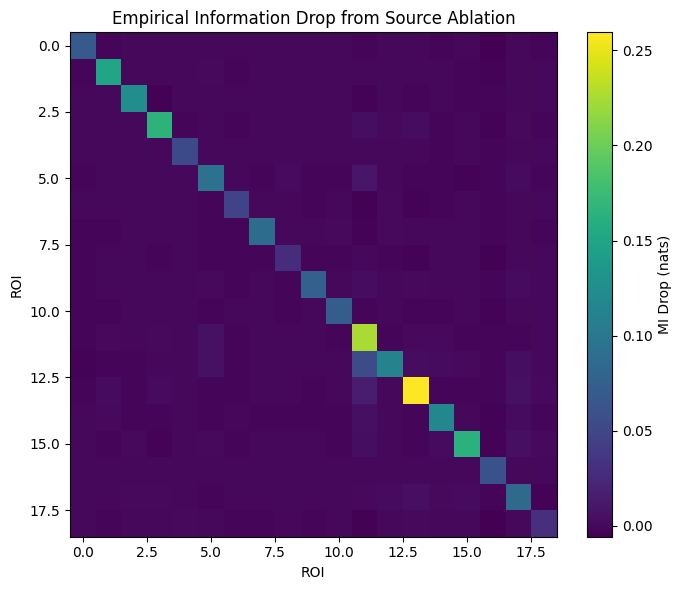

,source_roi,target_roi,empirical_mi_drop
227,12,11,0.054997
245,13,11,0.014357
100,5,11,0.010641
250,13,17,0.006397
203,11,5,0.005985
221,12,5,0.005928
286,15,17,0.005021
319,17,13,0.004985
263,14,11,0.004763
64,3,11,0.004648


Saved figure: results_paper/linear_regression/figures/top10_empirical_information_drop_pairs.png


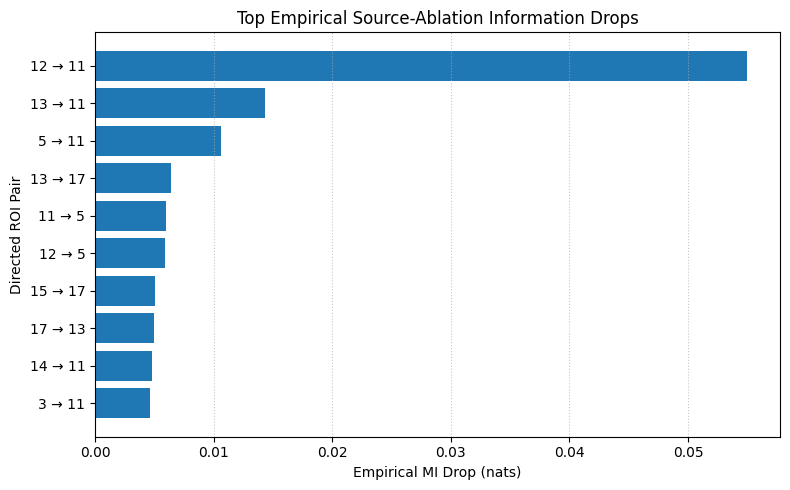

In [11]:
# ============================================================
# Empirical source-ablation information analysis
# ============================================================

def predict_with_source_replaced(source_roi, mode="mean"):
    X_mod = X_test.copy()

    if mode == "zero":
        X_mod[:, :, source_roi] = 0.0

    elif mode == "mean":
        source_mean = X_mod[:, :, source_roi].mean(axis=1, keepdims=True)
        X_mod[:, :, source_roi] = source_mean

    elif mode == "shuffle":
        rng = np.random.default_rng(CONFIG.random_state + source_roi)
        perm = rng.permutation(X_mod.shape[0])
        X_mod[:, :, source_roi] = X_mod[perm, :, source_roi]

    else:
        raise ValueError(f"Unknown mode: {mode}")

    X_mod_flat = flatten_features(X_mod)
    X_mod_scaled = scaler.transform(X_mod_flat)
    pred_mod_flat = model.predict(X_mod_scaled)
    return unflatten_predictions(pred_mod_flat, Y_test.shape)


def empirical_information_drop_matrix(mode="mean"):
    full = flatten_time_roi(preds)
    truth = flatten_time_roi(Y_test)
    n_roi = truth.shape[1]

    base_mi = np.array([
        empirical_mi_2d(truth[:, j], full[:, j], bins=CONFIG.bins)
        for j in range(n_roi)
    ])

    drop_mat = np.zeros((n_roi, n_roi), dtype=np.float64)

    for source_roi in range(n_roi):
        reduced_preds = predict_with_source_replaced(source_roi, mode=mode)
        reduced = flatten_time_roi(reduced_preds)

        for target_roi in range(n_roi):
            reduced_mi = empirical_mi_2d(
                truth[:, target_roi],
                reduced[:, target_roi],
                bins=CONFIG.bins,
            )
            drop_mat[source_roi, target_roi] = base_mi[target_roi] - reduced_mi

    return drop_mat


info_drop = empirical_information_drop_matrix(mode="mean")
save_matrix_csv(info_drop, "empirical_information_drop_matrix.csv")

plot_heatmap(
    info_drop,
    title="Empirical Information Drop from Source Ablation",
    filename="empirical_information_drop_heatmap.png",
    colorbar_label="MI Drop (nats)",
)

pairs = []
for i in range(info_drop.shape[0]):
    for j in range(info_drop.shape[1]):
        if i == j:
            continue
        pairs.append({
            "source_roi": i,
            "target_roi": j,
            "empirical_mi_drop": float(info_drop[i, j]),
        })

pairs_df = pd.DataFrame(pairs).sort_values("empirical_mi_drop", ascending=False)
pairs_df.to_csv(Path(CONFIG.results_dir) / "top_empirical_information_drop_pairs.csv", index=False)

display(pairs_df.head(15))

plt.figure(figsize=(8, 5))
top10 = pairs_df.head(10).copy()
labels = [f"{int(r.source_roi)} → {int(r.target_roi)}" for _, r in top10.iterrows()]
plt.barh(labels[::-1], top10["empirical_mi_drop"].values[::-1])
plt.xlabel("Empirical MI Drop (nats)")
plt.ylabel("Directed ROI Pair")
plt.title("Top Empirical Source-Ablation Information Drops")
plt.grid(axis="x", linestyle=":", alpha=0.7)
savefig("top10_empirical_information_drop_pairs.png")


Saved figure: results_paper/linear_regression/figures/temporal_weight_importance.png


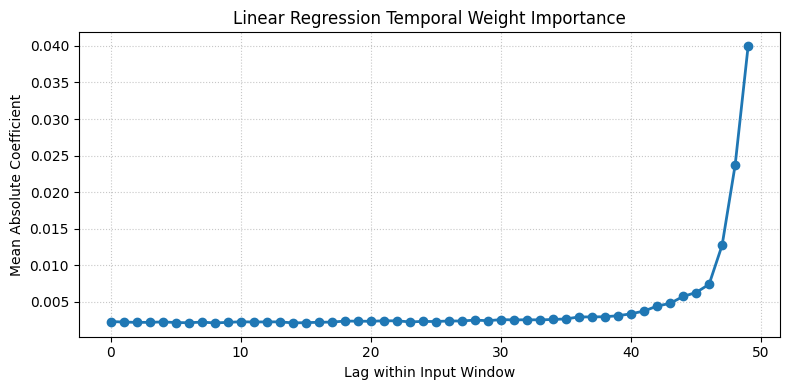

Saved figure: results_paper/linear_regression/figures/roi_to_roi_coefficient_importance.png


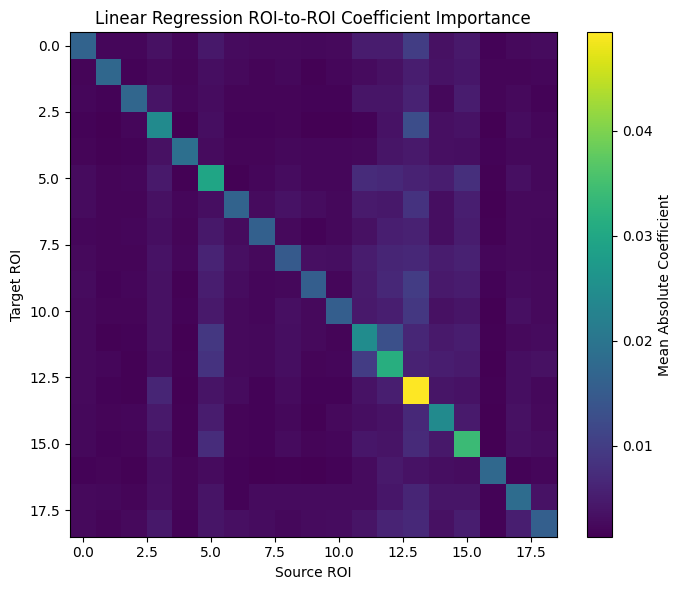

,source_roi,target_roi,mean_abs_coefficient
260,13,13,0.049368
300,15,15,0.034165
240,12,12,0.031397
100,5,5,0.029659
220,11,11,0.024668
60,3,3,0.024276
280,14,14,0.024265
80,4,4,0.018783
340,17,17,0.018219
320,16,16,0.017549


In [12]:
# ============================================================
# Linear regression coefficient analysis
# ============================================================

coef = np.asarray(model.coef_)

if coef.ndim != 2:
    raise ValueError(f"Unexpected coefficient shape: {coef.shape}")

target_dim = CONFIG.H * n_roi
feature_dim = CONFIG.M * n_roi

if coef.shape != (target_dim, feature_dim):
    raise ValueError(
        f"Expected coefficients {(target_dim, feature_dim)}, got {coef.shape}"
    )

coef_tensor = coef.reshape(CONFIG.H, n_roi, CONFIG.M, n_roi)
abs_coef = np.abs(coef_tensor)

temporal_importance = abs_coef.mean(axis=(0, 1, 3))
roi_to_roi_importance = abs_coef.mean(axis=(0, 2))

pd.DataFrame({
    "lag": np.arange(CONFIG.M),
    "mean_abs_weight": temporal_importance,
}).to_csv(Path(CONFIG.results_dir) / "temporal_weight_importance.csv", index=False)

pd.DataFrame(roi_to_roi_importance).to_csv(
    Path(CONFIG.results_dir) / "roi_to_roi_weight_importance.csv",
    index=False,
)

plt.figure(figsize=(8, 4))
plt.plot(np.arange(CONFIG.M), temporal_importance, marker="o", linewidth=2)
plt.xlabel("Lag within Input Window")
plt.ylabel("Mean Absolute Coefficient")
plt.title("Linear Regression Temporal Weight Importance")
plt.grid(True, linestyle=":", alpha=0.7)
savefig("temporal_weight_importance.png")

plt.figure(figsize=(7, 6))
plt.imshow(roi_to_roi_importance, aspect="auto", origin="upper")
plt.colorbar(label="Mean Absolute Coefficient")
plt.xlabel("Source ROI")
plt.ylabel("Target ROI")
plt.title("Linear Regression ROI-to-ROI Coefficient Importance")
savefig("roi_to_roi_coefficient_importance.png")

coef_pairs = []
for target_roi in range(n_roi):
    for source_roi in range(n_roi):
        coef_pairs.append({
            "source_roi": source_roi,
            "target_roi": target_roi,
            "mean_abs_coefficient": float(roi_to_roi_importance[target_roi, source_roi]),
        })

coef_pairs_df = pd.DataFrame(coef_pairs).sort_values(
    "mean_abs_coefficient",
    ascending=False,
)

coef_pairs_df.to_csv(
    Path(CONFIG.results_dir) / "top_roi_coefficient_connections.csv",
    index=False,
)

display(coef_pairs_df.head(15))


In [13]:
# ============================================================
# Final output inventory
# ============================================================

print("Saved result files:")
for path in sorted(Path(CONFIG.results_dir).glob("*")):
    if path.is_file():
        print(f" - {path}")

print("\nSaved figures:")
for path in sorted(Path(CONFIG.figure_dir).glob("*.png")):
    print(f" - {path}")


Saved result files:
 - results_paper/linear_regression/cross_roi_empirical_mi_difference_matrix.csv
 - results_paper/linear_regression/dataset_metadata.json
 - results_paper/linear_regression/empirical_information_drop_matrix.csv
 - results_paper/linear_regression/empirical_information_metrics_per_roi.csv
 - results_paper/linear_regression/empirical_residual_quantiles_by_roi.npz
 - results_paper/linear_regression/empirical_source_ablation_information_matrix.csv
 - results_paper/linear_regression/empirical_source_ablation_information_matrix.npy
 - results_paper/linear_regression/horizon_rmse.csv
 - results_paper/linear_regression/linear_coefficients_horizon_target_lag_source.npy
 - results_paper/linear_regression/metrics_summary.csv
 - results_paper/linear_regression/per_roi_metrics.csv
 - results_paper/linear_regression/predicted_cross_roi_empirical_mi_matrix.csv
 - results_paper/linear_regression/residual_stats.json
 - results_paper/linear_regression/roi_to_roi_weight_importance.csv
 